In [27]:
import numpy as np
import sys
import gvar as gv
# sys.path.append('/path/to/your/local')  # replace with the local path of your cloned GitHub repo
from Scaling_FT_HMC.utils.func import auto_from_chi
from Scaling_FT_HMC.utils.plot_settings import *
from Scaling_FT_HMC.utils.resampling import jackknife, jk_ls_avg

n_steps = 10
rand_seed_ls = [1029, 1107, 1331, 1984, 1999, 2008, 2017, 2025]

### L32 b3

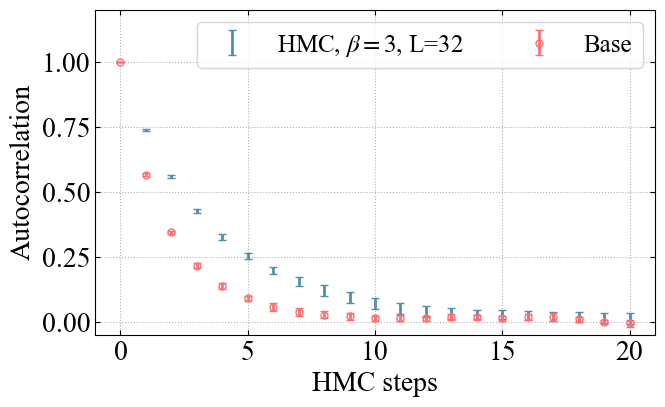

In [28]:
hmc_L32_b3_topo = {}
hmc_L32_b3_deltaQ = {}
for rand_seed in rand_seed_ls:
    hmc_L32_b3_topo[rand_seed] = np.loadtxt(f'../scaling/dumps/topo_hmc_L32_beta3.0_nsteps{n_steps}_{rand_seed}.csv')
    hmc_L32_b3_deltaQ[rand_seed] = np.mean([ abs(hmc_L32_b3_topo[rand_seed][i] - hmc_L32_b3_topo[rand_seed][i-1]) for i in range(1, len(hmc_L32_b3_topo[rand_seed])) ])

fthmc_base_L32_b3_topo = {}
fthmc_base_L32_b3_deltaQ = {}
for rand_seed in rand_seed_ls:
    fthmc_base_L32_b3_topo[rand_seed] = np.loadtxt(f'../scaling/dumps/topo_fthmc_L32_beta3.0_nsteps{n_steps}_base_train_b3.0_L32_{rand_seed}.csv')
    fthmc_base_L32_b3_deltaQ[rand_seed] = np.mean([ abs(fthmc_base_L32_b3_topo[rand_seed][i] - fthmc_base_L32_b3_topo[rand_seed][i-1]) for i in range(1, len(fthmc_base_L32_b3_topo[rand_seed]))])

beta = 3.0
max_lag = 20
volume = 32**2

hmc_L32_b3_auto = {}
for rand_seed in rand_seed_ls:
    hmc_L32_b3_auto[rand_seed] = auto_from_chi(hmc_L32_b3_topo[rand_seed], max_lag=max_lag, beta=beta, volume=volume)

fthmc_base_L32_b3_auto = {}
for rand_seed in rand_seed_ls:
    fthmc_base_L32_b3_auto[rand_seed] = auto_from_chi(fthmc_base_L32_b3_topo[rand_seed], max_lag=max_lag, beta=beta, volume=volume)

# * auto
hmc_L32_b3_auto_arr = np.array([hmc_L32_b3_auto[seed] for seed in rand_seed_ls])  # Shape: (8, max_lag + 1)
fthmc_base_L32_b3_auto_arr = np.array([fthmc_base_L32_b3_auto[seed] for seed in rand_seed_ls])  # Shape: (8, max_lag + 1)
jk_auto_arr = jackknife( np.concatenate([hmc_L32_b3_auto_arr, fthmc_base_L32_b3_auto_arr], axis=1) ) # concatenate for jk_ls_avg, shape: (8, 2 * max_lag + 2)
jk_auto_avg = jk_ls_avg(jk_auto_arr) # shape: (2 * max_lag + 2,)
hmc_L32_b3_auto_avg = jk_auto_avg[:max_lag+1]
fthmc_base_L32_b3_auto_avg = jk_auto_avg[max_lag+1:]

# * deltaQ
hmc_L32_b3_deltaQ_arr = np.array([hmc_L32_b3_deltaQ[seed] for seed in rand_seed_ls]).reshape(-1, 1) # Shape: (8, 1)
fthmc_base_L32_b3_deltaQ_arr = np.array([fthmc_base_L32_b3_deltaQ[seed] for seed in rand_seed_ls]).reshape(-1, 1) # Shape: (8, 1)
jk_deltaQ_arr = jackknife( np.concatenate([hmc_L32_b3_deltaQ_arr, fthmc_base_L32_b3_deltaQ_arr], axis=1) ) # concatenate for jk_ls_avg, shape: (8, 2)
jk_deltaQ_avg = jk_ls_avg(jk_deltaQ_arr) # shape: (2,)
hmc_L32_b3_deltaQ_avg = jk_deltaQ_avg[0]
fthmc_base_L32_b3_deltaQ_avg = jk_deltaQ_avg[1]

fig, ax = default_plot()
ax.errorbar(np.arange(len(hmc_L32_b3_auto_avg)), gv.mean(hmc_L32_b3_auto_avg), yerr=gv.sdev(hmc_L32_b3_auto_avg), label='HMC, $\\beta=3$, L=32', color=color_ls[0], **errorb)

ax.errorbar(np.arange(len(fthmc_base_L32_b3_auto_avg)), gv.mean(fthmc_base_L32_b3_auto_avg), yerr=gv.sdev(fthmc_base_L32_b3_auto_avg), label='Base', color=color_ls[3], **errorb_circle)

ax.set_ylim(-0.05, 1.2)
ax.legend(ncol=2, loc='upper right', **fs_small_p)
ax.set_xlabel('HMC steps', **fs_p)
ax.set_ylabel('Autocorrelation', **fs_p)
plt.tight_layout()
plt.savefig('plots/scaling_autocorrelation_L32_b3.pdf', transparent=True)
plt.show()


In [29]:
gamma_hmc = 1 / (1 - hmc_L32_b3_auto_avg[16])
gamma_fthmc = 1 / (1 - fthmc_base_L32_b3_auto_avg[16])
gamma_ratio_L32_b3 = gamma_hmc / gamma_fthmc
deltaQ_ratio_L32_b3 = fthmc_base_L32_b3_deltaQ_avg / hmc_L32_b3_deltaQ_avg

print(f"gamma ratio for L32 b3: {gamma_ratio_L32_b3}")
print(f"deltaQ ratio for L32 b3: {deltaQ_ratio_L32_b3}")


gamma ratio for L32 b3: 1.005(21)
deltaQ ratio for L32 b3: 1.328(29)


### L32 b4

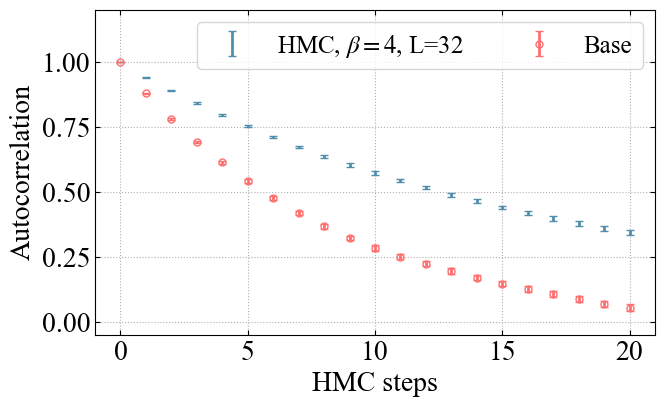

In [30]:
hmc_L32_b4_topo = {}
hmc_L32_b4_deltaQ = {}
for rand_seed in rand_seed_ls:
    hmc_L32_b4_topo[rand_seed] = np.loadtxt(f'../scaling/dumps/topo_hmc_L32_beta4.0_nsteps{n_steps}_{rand_seed}.csv')
    hmc_L32_b4_deltaQ[rand_seed] = np.mean([ abs(hmc_L32_b4_topo[rand_seed][i] - hmc_L32_b4_topo[rand_seed][i-1]) for i in range(1, len(hmc_L32_b4_topo[rand_seed])) ])

fthmc_base_L32_b4_topo = {}
fthmc_base_L32_b4_deltaQ = {}
for rand_seed in rand_seed_ls:
    fthmc_base_L32_b4_topo[rand_seed] = np.loadtxt(f'../scaling/dumps/topo_fthmc_L32_beta4.0_nsteps{n_steps}_base_train_b3.0_L32_{rand_seed}.csv')
    fthmc_base_L32_b4_deltaQ[rand_seed] = np.mean([ abs(fthmc_base_L32_b4_topo[rand_seed][i] - fthmc_base_L32_b4_topo[rand_seed][i-1]) for i in range(1, len(fthmc_base_L32_b4_topo[rand_seed]))])

beta = 4.0
max_lag = 20
volume = 32**2

hmc_L32_b4_auto = {}
for rand_seed in rand_seed_ls:
    hmc_L32_b4_auto[rand_seed] = auto_from_chi(hmc_L32_b4_topo[rand_seed], max_lag=max_lag, beta=beta, volume=volume)

fthmc_base_L32_b4_auto = {}
for rand_seed in rand_seed_ls:
    fthmc_base_L32_b4_auto[rand_seed] = auto_from_chi(fthmc_base_L32_b4_topo[rand_seed], max_lag=max_lag, beta=beta, volume=volume)

# * auto
hmc_L32_b4_auto_arr = np.array([hmc_L32_b4_auto[seed] for seed in rand_seed_ls])  # Shape: (8, max_lag + 1)
fthmc_base_L32_b4_auto_arr = np.array([fthmc_base_L32_b4_auto[seed] for seed in rand_seed_ls])  # Shape: (8, max_lag + 1)
jk_auto_arr = jackknife( np.concatenate([hmc_L32_b4_auto_arr, fthmc_base_L32_b4_auto_arr], axis=1) ) # concatenate for jk_ls_avg, shape: (8, 2 * max_lag + 2)
jk_auto_avg = jk_ls_avg(jk_auto_arr) # shape: (2 * max_lag + 2,)
hmc_L32_b4_auto_avg = jk_auto_avg[:max_lag+1]
fthmc_base_L32_b4_auto_avg = jk_auto_avg[max_lag+1:]

# * deltaQ
hmc_L32_b4_deltaQ_arr = np.array([hmc_L32_b4_deltaQ[seed] for seed in rand_seed_ls]).reshape(-1, 1) # Shape: (8, 1)
fthmc_base_L32_b4_deltaQ_arr = np.array([fthmc_base_L32_b4_deltaQ[seed] for seed in rand_seed_ls]).reshape(-1, 1) # Shape: (8, 1)
jk_deltaQ_arr = jackknife( np.concatenate([hmc_L32_b4_deltaQ_arr, fthmc_base_L32_b4_deltaQ_arr], axis=1) ) # concatenate for jk_ls_avg, shape: (8, 2)
jk_deltaQ_avg = jk_ls_avg(jk_deltaQ_arr) # shape: (2,)
hmc_L32_b4_deltaQ_avg = jk_deltaQ_avg[0]
fthmc_base_L32_b4_deltaQ_avg = jk_deltaQ_avg[1]

fig, ax = default_plot()
ax.errorbar(np.arange(len(hmc_L32_b4_auto_avg)), gv.mean(hmc_L32_b4_auto_avg), yerr=gv.sdev(hmc_L32_b4_auto_avg), label='HMC, $\\beta=4$, L=32', color=color_ls[0], **errorb)

ax.errorbar(np.arange(len(fthmc_base_L32_b4_auto_avg)), gv.mean(fthmc_base_L32_b4_auto_avg), yerr=gv.sdev(fthmc_base_L32_b4_auto_avg), label='Base', color=color_ls[3], **errorb_circle)

ax.set_ylim(-0.05, 1.2)
ax.legend(ncol=2, loc='upper right', **fs_small_p)
ax.set_xlabel('HMC steps', **fs_p)
ax.set_ylabel('Autocorrelation', **fs_p)
plt.tight_layout()
plt.savefig('plots/scaling_autocorrelation_L32_b4.pdf', transparent=True)
plt.show()


In [31]:
gamma_hmc = 1 / (1 - hmc_L32_b4_auto_avg[16])
gamma_fthmc = 1 / (1 - fthmc_base_L32_b4_auto_avg[16])
gamma_ratio_L32_b4 = gamma_hmc / gamma_fthmc
deltaQ_ratio_L32_b4 = fthmc_base_L32_b4_deltaQ_avg / hmc_L32_b4_deltaQ_avg

print(f"gamma ratio for L32 b4: {gamma_ratio_L32_b4}")
print(f"deltaQ ratio for L32 b4: {deltaQ_ratio_L32_b4}")

gamma ratio for L32 b4: 1.501(28)
deltaQ ratio for L32 b4: 1.550(13)


### L32 b5

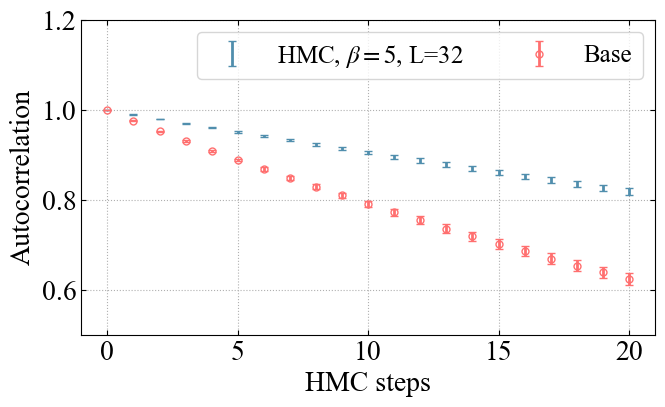

In [32]:
hmc_L32_b5_topo = {}
hmc_L32_b5_deltaQ = {}
for rand_seed in rand_seed_ls:
    hmc_L32_b5_topo[rand_seed] = np.loadtxt(f'../scaling/dumps/topo_hmc_L32_beta5.0_nsteps{n_steps}_{rand_seed}.csv')
    hmc_L32_b5_deltaQ[rand_seed] = np.mean([ abs(hmc_L32_b5_topo[rand_seed][i] - hmc_L32_b5_topo[rand_seed][i-1]) for i in range(1, len(hmc_L32_b5_topo[rand_seed])) ])

fthmc_base_L32_b5_topo = {}
fthmc_base_L32_b5_deltaQ = {}
for rand_seed in rand_seed_ls:
    fthmc_base_L32_b5_topo[rand_seed] = np.loadtxt(f'../scaling/dumps/topo_fthmc_L32_beta5.0_nsteps{n_steps}_base_train_b3.0_L32_{rand_seed}.csv')
    fthmc_base_L32_b5_deltaQ[rand_seed] = np.mean([ abs(fthmc_base_L32_b5_topo[rand_seed][i] - fthmc_base_L32_b5_topo[rand_seed][i-1]) for i in range(1, len(fthmc_base_L32_b5_topo[rand_seed]))])

beta = 5.0
max_lag = 20
volume = 32**2

hmc_L32_b5_auto = {}
for rand_seed in rand_seed_ls:
    hmc_L32_b5_auto[rand_seed] = auto_from_chi(hmc_L32_b5_topo[rand_seed], max_lag=max_lag, beta=beta, volume=volume)

fthmc_base_L32_b5_auto = {}
for rand_seed in rand_seed_ls:
    fthmc_base_L32_b5_auto[rand_seed] = auto_from_chi(fthmc_base_L32_b5_topo[rand_seed], max_lag=max_lag, beta=beta, volume=volume)

# * auto
hmc_L32_b5_auto_arr = np.array([hmc_L32_b5_auto[seed] for seed in rand_seed_ls])  # Shape: (8, max_lag + 1)
fthmc_base_L32_b5_auto_arr = np.array([fthmc_base_L32_b5_auto[seed] for seed in rand_seed_ls])  # Shape: (8, max_lag + 1)
jk_auto_arr = jackknife( np.concatenate([hmc_L32_b5_auto_arr, fthmc_base_L32_b5_auto_arr], axis=1) ) # concatenate for jk_ls_avg, shape: (8, 2 * max_lag + 2)
jk_auto_avg = jk_ls_avg(jk_auto_arr) # shape: (2 * max_lag + 2,)
hmc_L32_b5_auto_avg = jk_auto_avg[:max_lag+1]
fthmc_base_L32_b5_auto_avg = jk_auto_avg[max_lag+1:]

# * deltaQ
hmc_L32_b5_deltaQ_arr = np.array([hmc_L32_b5_deltaQ[seed] for seed in rand_seed_ls]).reshape(-1, 1) # Shape: (8, 1)
fthmc_base_L32_b5_deltaQ_arr = np.array([fthmc_base_L32_b5_deltaQ[seed] for seed in rand_seed_ls]).reshape(-1, 1) # Shape: (8, 1)
jk_deltaQ_arr = jackknife( np.concatenate([hmc_L32_b5_deltaQ_arr, fthmc_base_L32_b5_deltaQ_arr], axis=1) ) # concatenate for jk_ls_avg, shape: (8, 2)
jk_deltaQ_avg = jk_ls_avg(jk_deltaQ_arr) # shape: (2,)
hmc_L32_b5_deltaQ_avg = jk_deltaQ_avg[0]
fthmc_base_L32_b5_deltaQ_avg = jk_deltaQ_avg[1]

fig, ax = default_plot()
ax.errorbar(np.arange(len(hmc_L32_b5_auto_avg)), gv.mean(hmc_L32_b5_auto_avg), yerr=gv.sdev(hmc_L32_b5_auto_avg), label='HMC, $\\beta=5$, L=32', color=color_ls[0], **errorb)

ax.errorbar(np.arange(len(fthmc_base_L32_b5_auto_avg)), gv.mean(fthmc_base_L32_b5_auto_avg), yerr=gv.sdev(fthmc_base_L32_b5_auto_avg), label='Base', color=color_ls[3], **errorb_circle)

ax.set_ylim(0.5, 1.2)
ax.legend(ncol=2, loc='upper right', **fs_small_p)
ax.set_xlabel('HMC steps', **fs_p)
ax.set_ylabel('Autocorrelation', **fs_p)
plt.tight_layout()
plt.savefig('plots/scaling_autocorrelation_L32_b5.pdf', transparent=True)
plt.show()


In [33]:
gamma_hmc = 1 / (1 - hmc_L32_b5_auto_avg[16])
gamma_fthmc = 1 / (1 - fthmc_base_L32_b5_auto_avg[16])
gamma_ratio_L32_b5 = gamma_hmc / gamma_fthmc
deltaQ_ratio_L32_b5 = fthmc_base_L32_b5_deltaQ_avg / hmc_L32_b5_deltaQ_avg

print(f"gamma ratio for L32 b5: {gamma_ratio_L32_b5}")
print(f"deltaQ ratio for L32 b5: {deltaQ_ratio_L32_b5}")


gamma ratio for L32 b5: 2.13(11)
deltaQ ratio for L32 b5: 1.936(47)


### L32 b6

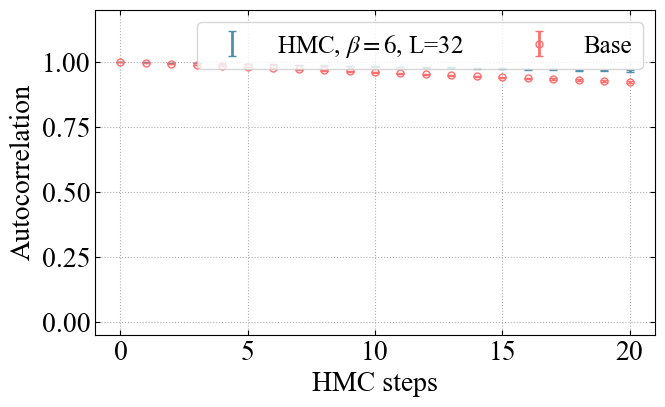

In [34]:
hmc_L32_b6_topo = {}
hmc_L32_b6_deltaQ = {}
for rand_seed in rand_seed_ls:
    hmc_L32_b6_topo[rand_seed] = np.loadtxt(f'../scaling/dumps/topo_hmc_L32_beta6.0_nsteps{n_steps}_{rand_seed}.csv')
    hmc_L32_b6_deltaQ[rand_seed] = np.mean([ abs(hmc_L32_b6_topo[rand_seed][i] - hmc_L32_b6_topo[rand_seed][i-1]) for i in range(1, len(hmc_L32_b6_topo[rand_seed])) ])

fthmc_base_L32_b6_topo = {}
fthmc_base_L32_b6_deltaQ = {}
for rand_seed in rand_seed_ls:
    fthmc_base_L32_b6_topo[rand_seed] = np.loadtxt(f'../scaling/dumps/topo_fthmc_L32_beta6.0_nsteps{n_steps}_base_train_b3.0_L32_{rand_seed}.csv')
    fthmc_base_L32_b6_deltaQ[rand_seed] = np.mean([ abs(fthmc_base_L32_b6_topo[rand_seed][i] - fthmc_base_L32_b6_topo[rand_seed][i-1]) for i in range(1, len(fthmc_base_L32_b6_topo[rand_seed]))])

beta = 6.0
max_lag = 20
volume = 32**2

hmc_L32_b6_auto = {}
for rand_seed in rand_seed_ls:
    hmc_L32_b6_auto[rand_seed] = auto_from_chi(hmc_L32_b6_topo[rand_seed], max_lag=max_lag, beta=beta, volume=volume)

fthmc_base_L32_b6_auto = {}
for rand_seed in rand_seed_ls:
    fthmc_base_L32_b6_auto[rand_seed] = auto_from_chi(fthmc_base_L32_b6_topo[rand_seed], max_lag=max_lag, beta=beta, volume=volume)

# * auto
hmc_L32_b6_auto_arr = np.array([hmc_L32_b6_auto[seed] for seed in rand_seed_ls])  # Shape: (8, max_lag + 1)
fthmc_base_L32_b6_auto_arr = np.array([fthmc_base_L32_b6_auto[seed] for seed in rand_seed_ls])  # Shape: (8, max_lag + 1)
jk_auto_arr = jackknife( np.concatenate([hmc_L32_b6_auto_arr, fthmc_base_L32_b6_auto_arr], axis=1) ) # concatenate for jk_ls_avg, shape: (8, 2 * max_lag + 2)
jk_auto_avg = jk_ls_avg(jk_auto_arr) # shape: (2 * max_lag + 2,)
hmc_L32_b6_auto_avg = jk_auto_avg[:max_lag+1]
fthmc_base_L32_b6_auto_avg = jk_auto_avg[max_lag+1:]

# * deltaQ
hmc_L32_b6_deltaQ_arr = np.array([hmc_L32_b6_deltaQ[seed] for seed in rand_seed_ls]).reshape(-1, 1) # Shape: (8, 1)
fthmc_base_L32_b6_deltaQ_arr = np.array([fthmc_base_L32_b6_deltaQ[seed] for seed in rand_seed_ls]).reshape(-1, 1) # Shape: (8, 1)
jk_deltaQ_arr = jackknife( np.concatenate([hmc_L32_b6_deltaQ_arr, fthmc_base_L32_b6_deltaQ_arr], axis=1) ) # concatenate for jk_ls_avg, shape: (8, 2)
jk_deltaQ_avg = jk_ls_avg(jk_deltaQ_arr) # shape: (2,)
hmc_L32_b6_deltaQ_avg = jk_deltaQ_avg[0]
fthmc_base_L32_b6_deltaQ_avg = jk_deltaQ_avg[1]

fig, ax = default_plot()
ax.errorbar(np.arange(len(hmc_L32_b6_auto_avg)), gv.mean(hmc_L32_b6_auto_avg), yerr=gv.sdev(hmc_L32_b6_auto_avg), label='HMC, $\\beta=6$, L=32', color=color_ls[0], **errorb)

ax.errorbar(np.arange(len(fthmc_base_L32_b6_auto_avg)), gv.mean(fthmc_base_L32_b6_auto_avg), yerr=gv.sdev(fthmc_base_L32_b6_auto_avg), label='Base', color=color_ls[3], **errorb_circle)

ax.set_ylim(-0.05, 1.2)
ax.legend(ncol=2, loc='upper right', **fs_small_p)
ax.set_xlabel('HMC steps', **fs_p)
ax.set_ylabel('Autocorrelation', **fs_p)
plt.tight_layout()
plt.savefig('plots/scaling_autocorrelation_L32_b6.pdf', transparent=True)
plt.show()


In [35]:
gamma_hmc = 1 / (1 - hmc_L32_b6_auto_avg[16])
gamma_fthmc = 1 / (1 - fthmc_base_L32_b6_auto_avg[16])
gamma_ratio_L32_b6 = gamma_hmc / gamma_fthmc
deltaQ_ratio_L32_b6 = fthmc_base_L32_b6_deltaQ_avg / hmc_L32_b6_deltaQ_avg

print(f"gamma ratio for L32 b6: {gamma_ratio_L32_b6}")
print(f"deltaQ ratio for L32 b6: {deltaQ_ratio_L32_b6}")


gamma ratio for L32 b6: 2.24(20)
deltaQ ratio for L32 b6: 2.15(12)


### L64 b3

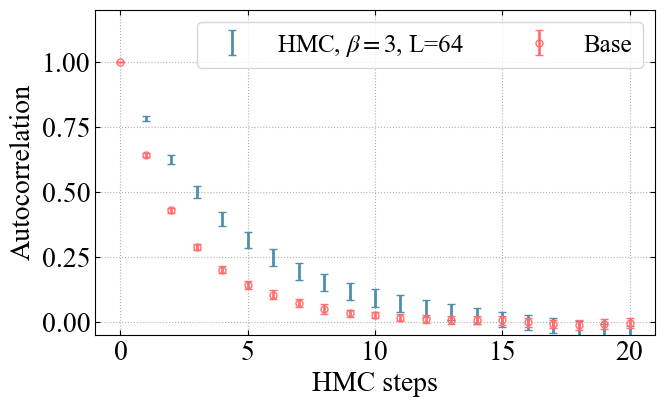

In [36]:
hmc_L64_b3_topo = {}
hmc_L64_b3_deltaQ = {}
for rand_seed in rand_seed_ls:
    hmc_L64_b3_topo[rand_seed] = np.loadtxt(f'../scaling/dumps/topo_hmc_L64_beta3.0_nsteps{n_steps}_{rand_seed}.csv')
    hmc_L64_b3_deltaQ[rand_seed] = np.mean([ abs(hmc_L64_b3_topo[rand_seed][i] - hmc_L64_b3_topo[rand_seed][i-1]) for i in range(1, len(hmc_L64_b3_topo[rand_seed])) ])

fthmc_base_L64_b3_topo = {}
fthmc_base_L64_b3_deltaQ = {}
for rand_seed in rand_seed_ls:
    fthmc_base_L64_b3_topo[rand_seed] = np.loadtxt(f'../scaling/dumps/topo_fthmc_L64_beta3.0_nsteps{n_steps}_base_train_b3.0_L32_{rand_seed}.csv')
    fthmc_base_L64_b3_deltaQ[rand_seed] = np.mean([ abs(fthmc_base_L64_b3_topo[rand_seed][i] - fthmc_base_L64_b3_topo[rand_seed][i-1]) for i in range(1, len(fthmc_base_L64_b3_topo[rand_seed]))])

beta = 3.0
max_lag = 20
volume = 64**2

hmc_L64_b3_auto = {}
for rand_seed in rand_seed_ls:
    hmc_L64_b3_auto[rand_seed] = auto_from_chi(hmc_L64_b3_topo[rand_seed], max_lag=max_lag, beta=beta, volume=volume)

fthmc_base_L64_b3_auto = {}
for rand_seed in rand_seed_ls:
    fthmc_base_L64_b3_auto[rand_seed] = auto_from_chi(fthmc_base_L64_b3_topo[rand_seed], max_lag=max_lag, beta=beta, volume=volume)

# * auto
hmc_L64_b3_auto_arr = np.array([hmc_L64_b3_auto[seed] for seed in rand_seed_ls])  # Shape: (8, max_lag + 1)
fthmc_base_L64_b3_auto_arr = np.array([fthmc_base_L64_b3_auto[seed] for seed in rand_seed_ls])  # Shape: (8, max_lag + 1)
jk_auto_arr = jackknife( np.concatenate([hmc_L64_b3_auto_arr, fthmc_base_L64_b3_auto_arr], axis=1) ) # concatenate for jk_ls_avg, shape: (8, 2 * max_lag + 2)
jk_auto_avg = jk_ls_avg(jk_auto_arr) # shape: (2 * max_lag + 2,)
hmc_L64_b3_auto_avg = jk_auto_avg[:max_lag+1]
fthmc_base_L64_b3_auto_avg = jk_auto_avg[max_lag+1:]

# * deltaQ
hmc_L64_b3_deltaQ_arr = np.array([hmc_L64_b3_deltaQ[seed] for seed in rand_seed_ls]).reshape(-1, 1) # Shape: (8, 1)
fthmc_base_L64_b3_deltaQ_arr = np.array([fthmc_base_L64_b3_deltaQ[seed] for seed in rand_seed_ls]).reshape(-1, 1) # Shape: (8, 1)
jk_deltaQ_arr = jackknife( np.concatenate([hmc_L64_b3_deltaQ_arr, fthmc_base_L64_b3_deltaQ_arr], axis=1) ) # concatenate for jk_ls_avg, shape: (8, 2)
jk_deltaQ_avg = jk_ls_avg(jk_deltaQ_arr) # shape: (2,)
hmc_L64_b3_deltaQ_avg = jk_deltaQ_avg[0]
fthmc_base_L64_b3_deltaQ_avg = jk_deltaQ_avg[1]

fig, ax = default_plot()
ax.errorbar(np.arange(len(hmc_L64_b3_auto_avg)), gv.mean(hmc_L64_b3_auto_avg), yerr=gv.sdev(hmc_L64_b3_auto_avg), label='HMC, $\\beta=3$, L=64', color=color_ls[0], **errorb)

ax.errorbar(np.arange(len(fthmc_base_L64_b3_auto_avg)), gv.mean(fthmc_base_L64_b3_auto_avg), yerr=gv.sdev(fthmc_base_L64_b3_auto_avg), label='Base', color=color_ls[3], **errorb_circle)

ax.set_ylim(-0.05, 1.2)
ax.legend(ncol=2, loc='upper right', **fs_small_p)
ax.set_xlabel('HMC steps', **fs_p)
ax.set_ylabel('Autocorrelation', **fs_p)
plt.tight_layout()
plt.savefig('plots/scaling_autocorrelation_L64_b3.pdf', transparent=True)
plt.show()


In [37]:
gamma_hmc = 1 / (1 - hmc_L64_b3_auto_avg[16])
gamma_fthmc = 1 / (1 - fthmc_base_L64_b3_auto_avg[16])
gamma_ratio_L64_b3 = gamma_hmc / gamma_fthmc
deltaQ_ratio_L64_b3 = fthmc_base_L64_b3_deltaQ_avg / hmc_L64_b3_deltaQ_avg

print(f"gamma ratio for L64 b3: {gamma_ratio_L64_b3}")
print(f"deltaQ ratio for L64 b3: {deltaQ_ratio_L64_b3}")


gamma ratio for L64 b3: 0.999(34)
deltaQ ratio for L64 b3: 1.171(31)


### L64 b4

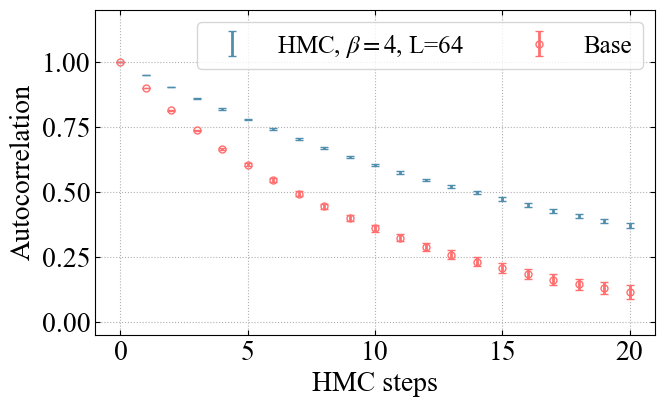

In [38]:
hmc_L64_b4_topo = {}
hmc_L64_b4_deltaQ = {}
for rand_seed in rand_seed_ls:
    hmc_L64_b4_topo[rand_seed] = np.loadtxt(f'../scaling/dumps/topo_hmc_L64_beta4.0_nsteps{n_steps}_{rand_seed}.csv')
    hmc_L64_b4_deltaQ[rand_seed] = np.mean([ abs(hmc_L64_b4_topo[rand_seed][i] - hmc_L64_b4_topo[rand_seed][i-1]) for i in range(1, len(hmc_L64_b4_topo[rand_seed])) ])

fthmc_base_L64_b4_topo = {}
fthmc_base_L64_b4_deltaQ = {}
for rand_seed in rand_seed_ls:
    fthmc_base_L64_b4_topo[rand_seed] = np.loadtxt(f'../scaling/dumps/topo_fthmc_L64_beta4.0_nsteps{n_steps}_base_train_b3.0_L32_{rand_seed}.csv')
    fthmc_base_L64_b4_deltaQ[rand_seed] = np.mean([ abs(fthmc_base_L64_b4_topo[rand_seed][i] - fthmc_base_L64_b4_topo[rand_seed][i-1]) for i in range(1, len(fthmc_base_L64_b4_topo[rand_seed]))])

beta = 4.0
max_lag = 20
volume = 64**2

hmc_L64_b4_auto = {}
for rand_seed in rand_seed_ls:
    hmc_L64_b4_auto[rand_seed] = auto_from_chi(hmc_L64_b4_topo[rand_seed], max_lag=max_lag, beta=beta, volume=volume)

fthmc_base_L64_b4_auto = {}
for rand_seed in rand_seed_ls:
    fthmc_base_L64_b4_auto[rand_seed] = auto_from_chi(fthmc_base_L64_b4_topo[rand_seed], max_lag=max_lag, beta=beta, volume=volume)

# * auto
hmc_L64_b4_auto_arr = np.array([hmc_L64_b4_auto[seed] for seed in rand_seed_ls])  # Shape: (8, max_lag + 1)
fthmc_base_L64_b4_auto_arr = np.array([fthmc_base_L64_b4_auto[seed] for seed in rand_seed_ls])  # Shape: (8, max_lag + 1)
jk_auto_arr = jackknife( np.concatenate([hmc_L64_b4_auto_arr, fthmc_base_L64_b4_auto_arr], axis=1) ) # concatenate for jk_ls_avg, shape: (8, 2 * max_lag + 2)
jk_auto_avg = jk_ls_avg(jk_auto_arr) # shape: (2 * max_lag + 2,)
hmc_L64_b4_auto_avg = jk_auto_avg[:max_lag+1]
fthmc_base_L64_b4_auto_avg = jk_auto_avg[max_lag+1:]

# * deltaQ
hmc_L64_b4_deltaQ_arr = np.array([hmc_L64_b4_deltaQ[seed] for seed in rand_seed_ls]).reshape(-1, 1) # Shape: (8, 1)
fthmc_base_L64_b4_deltaQ_arr = np.array([fthmc_base_L64_b4_deltaQ[seed] for seed in rand_seed_ls]).reshape(-1, 1) # Shape: (8, 1)
jk_deltaQ_arr = jackknife( np.concatenate([hmc_L64_b4_deltaQ_arr, fthmc_base_L64_b4_deltaQ_arr], axis=1) ) # concatenate for jk_ls_avg, shape: (8, 2)
jk_deltaQ_avg = jk_ls_avg(jk_deltaQ_arr) # shape: (2,)
hmc_L64_b4_deltaQ_avg = jk_deltaQ_avg[0]
fthmc_base_L64_b4_deltaQ_avg = jk_deltaQ_avg[1]

fig, ax = default_plot()
ax.errorbar(np.arange(len(hmc_L64_b4_auto_avg)), gv.mean(hmc_L64_b4_auto_avg), yerr=gv.sdev(hmc_L64_b4_auto_avg), label='HMC, $\\beta=4$, L=64', color=color_ls[0], **errorb)

ax.errorbar(np.arange(len(fthmc_base_L64_b4_auto_avg)), gv.mean(fthmc_base_L64_b4_auto_avg), yerr=gv.sdev(fthmc_base_L64_b4_auto_avg), label='Base', color=color_ls[3], **errorb_circle)

ax.set_ylim(-0.05, 1.2)
ax.legend(ncol=2, loc='upper right', **fs_small_p)
ax.set_xlabel('HMC steps', **fs_p)
ax.set_ylabel('Autocorrelation', **fs_p)
plt.tight_layout()
plt.savefig('plots/scaling_autocorrelation_L64_b4.pdf', transparent=True)
plt.show()


In [39]:
gamma_hmc = 1 / (1 - hmc_L64_b4_auto_avg[16])
gamma_fthmc = 1 / (1 - fthmc_base_L64_b4_auto_avg[16])
gamma_ratio_L64_b4 = gamma_hmc / gamma_fthmc
deltaQ_ratio_L64_b4 = fthmc_base_L64_b4_deltaQ_avg / hmc_L64_b4_deltaQ_avg

print(f"gamma ratio for L64 b4: {gamma_ratio_L64_b4}")
print(f"deltaQ ratio for L64 b4: {deltaQ_ratio_L64_b4}")


gamma ratio for L64 b4: 1.479(40)
deltaQ ratio for L64 b4: 1.398(16)


### L64 b5

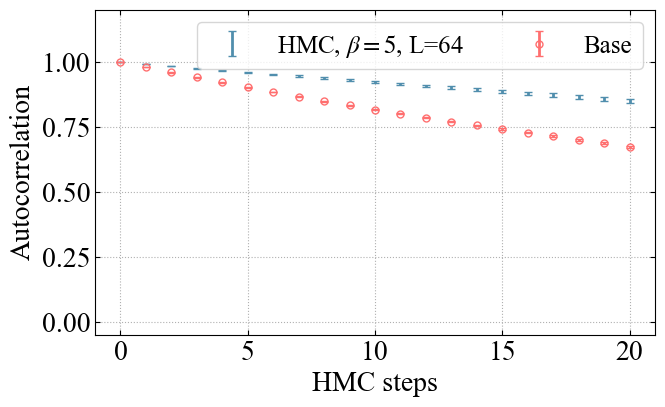

In [40]:
hmc_L64_b5_topo = {}
hmc_L64_b5_deltaQ = {}
for rand_seed in rand_seed_ls:
    hmc_L64_b5_topo[rand_seed] = np.loadtxt(f'../scaling/dumps/topo_hmc_L64_beta5.0_nsteps{n_steps}_{rand_seed}.csv')
    hmc_L64_b5_deltaQ[rand_seed] = np.mean([ abs(hmc_L64_b5_topo[rand_seed][i] - hmc_L64_b5_topo[rand_seed][i-1]) for i in range(1, len(hmc_L64_b5_topo[rand_seed])) ])

fthmc_base_L64_b5_topo = {}
fthmc_base_L64_b5_deltaQ = {}
for rand_seed in rand_seed_ls:
    fthmc_base_L64_b5_topo[rand_seed] = np.loadtxt(f'../scaling/dumps/topo_fthmc_L64_beta5.0_nsteps{n_steps}_base_train_b3.0_L32_{rand_seed}.csv')
    fthmc_base_L64_b5_deltaQ[rand_seed] = np.mean([ abs(fthmc_base_L64_b5_topo[rand_seed][i] - fthmc_base_L64_b5_topo[rand_seed][i-1]) for i in range(1, len(fthmc_base_L64_b5_topo[rand_seed]))])

beta = 5.0
max_lag = 20
volume = 64**2

hmc_L64_b5_auto = {}
for rand_seed in rand_seed_ls:
    hmc_L64_b5_auto[rand_seed] = auto_from_chi(hmc_L64_b5_topo[rand_seed], max_lag=max_lag, beta=beta, volume=volume)

fthmc_base_L64_b5_auto = {}
for rand_seed in rand_seed_ls:
    fthmc_base_L64_b5_auto[rand_seed] = auto_from_chi(fthmc_base_L64_b5_topo[rand_seed], max_lag=max_lag, beta=beta, volume=volume)

# * auto
hmc_L64_b5_auto_arr = np.array([hmc_L64_b5_auto[seed] for seed in rand_seed_ls])  # Shape: (8, max_lag + 1)
fthmc_base_L64_b5_auto_arr = np.array([fthmc_base_L64_b5_auto[seed] for seed in rand_seed_ls])  # Shape: (8, max_lag + 1)
jk_auto_arr = jackknife( np.concatenate([hmc_L64_b5_auto_arr, fthmc_base_L64_b5_auto_arr], axis=1) ) # concatenate for jk_ls_avg, shape: (8, 2 * max_lag + 2)
jk_auto_avg = jk_ls_avg(jk_auto_arr) # shape: (2 * max_lag + 2,)
hmc_L64_b5_auto_avg = jk_auto_avg[:max_lag+1]
fthmc_base_L64_b5_auto_avg = jk_auto_avg[max_lag+1:]

# * deltaQ
hmc_L64_b5_deltaQ_arr = np.array([hmc_L64_b5_deltaQ[seed] for seed in rand_seed_ls]).reshape(-1, 1) # Shape: (8, 1)
fthmc_base_L64_b5_deltaQ_arr = np.array([fthmc_base_L64_b5_deltaQ[seed] for seed in rand_seed_ls]).reshape(-1, 1) # Shape: (8, 1)
jk_deltaQ_arr = jackknife( np.concatenate([hmc_L64_b5_deltaQ_arr, fthmc_base_L64_b5_deltaQ_arr], axis=1) ) # concatenate for jk_ls_avg, shape: (8, 2)
jk_deltaQ_avg = jk_ls_avg(jk_deltaQ_arr) # shape: (2,)
hmc_L64_b5_deltaQ_avg = jk_deltaQ_avg[0]
fthmc_base_L64_b5_deltaQ_avg = jk_deltaQ_avg[1]

fig, ax = default_plot()
ax.errorbar(np.arange(len(hmc_L64_b5_auto_avg)), gv.mean(hmc_L64_b5_auto_avg), yerr=gv.sdev(hmc_L64_b5_auto_avg), label='HMC, $\\beta=5$, L=64', color=color_ls[0], **errorb)

ax.errorbar(np.arange(len(fthmc_base_L64_b5_auto_avg)), gv.mean(fthmc_base_L64_b5_auto_avg), yerr=gv.sdev(fthmc_base_L64_b5_auto_avg), label='Base', color=color_ls[3], **errorb_circle)

ax.set_ylim(-0.05, 1.2)
ax.legend(ncol=2, loc='upper right', **fs_small_p)
ax.set_xlabel('HMC steps', **fs_p)
ax.set_ylabel('Autocorrelation', **fs_p)
plt.tight_layout()
plt.savefig('plots/scaling_autocorrelation_L64_b5.pdf', transparent=True)
plt.show()


In [41]:
gamma_hmc = 1 / (1 - hmc_L64_b5_auto_avg[16])
gamma_fthmc = 1 / (1 - fthmc_base_L64_b5_auto_avg[16])
gamma_ratio_L64_b5 = gamma_hmc / gamma_fthmc
deltaQ_ratio_L64_b5 = fthmc_base_L64_b5_deltaQ_avg / hmc_L64_b5_deltaQ_avg

print(f"gamma ratio for L64 b5: {gamma_ratio_L64_b5}")
print(f"deltaQ ratio for L64 b5: {deltaQ_ratio_L64_b5}")


gamma ratio for L64 b5: 2.24(12)
deltaQ ratio for L64 b5: 1.801(99)


### L64 b6

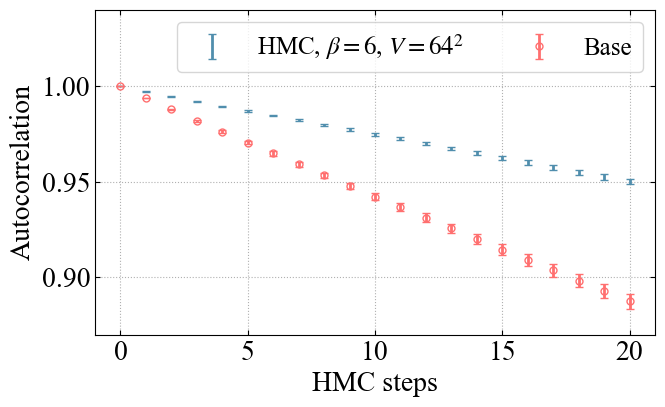

In [42]:
hmc_L64_b6_topo = {}
hmc_L64_b6_deltaQ = {}
for rand_seed in rand_seed_ls:
    hmc_L64_b6_topo[rand_seed] = np.loadtxt(f'../scaling/dumps/topo_hmc_L64_beta6.0_nsteps{n_steps}_{rand_seed}.csv')
    hmc_L64_b6_deltaQ[rand_seed] = np.mean([ abs(hmc_L64_b6_topo[rand_seed][i] - hmc_L64_b6_topo[rand_seed][i-1]) for i in range(1, len(hmc_L64_b6_topo[rand_seed])) ])

fthmc_base_L64_b6_topo = {}
fthmc_base_L64_b6_deltaQ = {}
for rand_seed in rand_seed_ls:
    fthmc_base_L64_b6_topo[rand_seed] = np.loadtxt(f'../scaling/dumps/topo_fthmc_L64_beta6.0_nsteps{n_steps}_base_train_b3.0_L32_{rand_seed}.csv')
    fthmc_base_L64_b6_deltaQ[rand_seed] = np.mean([ abs(fthmc_base_L64_b6_topo[rand_seed][i] - fthmc_base_L64_b6_topo[rand_seed][i-1]) for i in range(1, len(fthmc_base_L64_b6_topo[rand_seed]))])

beta = 3.0
max_lag = 20
volume = 32**2

hmc_L64_b6_auto = {}
for rand_seed in rand_seed_ls:
    hmc_L64_b6_auto[rand_seed] = auto_from_chi(hmc_L64_b6_topo[rand_seed], max_lag=max_lag, beta=beta, volume=volume)

fthmc_base_L64_b6_auto = {}
for rand_seed in rand_seed_ls:
    fthmc_base_L64_b6_auto[rand_seed] = auto_from_chi(fthmc_base_L64_b6_topo[rand_seed], max_lag=max_lag, beta=beta, volume=volume)

# * auto
hmc_L64_b6_auto_arr = np.array([hmc_L64_b6_auto[seed] for seed in rand_seed_ls])  # Shape: (8, max_lag + 1)
fthmc_base_L64_b6_auto_arr = np.array([fthmc_base_L64_b6_auto[seed] for seed in rand_seed_ls])  # Shape: (8, max_lag + 1)
jk_auto_arr = jackknife( np.concatenate([hmc_L64_b6_auto_arr, fthmc_base_L64_b6_auto_arr], axis=1) ) # concatenate for jk_ls_avg, shape: (8, 2 * max_lag + 2)
jk_auto_avg = jk_ls_avg(jk_auto_arr) # shape: (2 * max_lag + 2,)
hmc_L64_b6_auto_avg = jk_auto_avg[:max_lag+1]
fthmc_base_L64_b6_auto_avg = jk_auto_avg[max_lag+1:]

# * deltaQ
hmc_L64_b6_deltaQ_arr = np.array([hmc_L64_b6_deltaQ[seed] for seed in rand_seed_ls]).reshape(-1, 1) # Shape: (8, 1)
fthmc_base_L64_b6_deltaQ_arr = np.array([fthmc_base_L64_b6_deltaQ[seed] for seed in rand_seed_ls]).reshape(-1, 1) # Shape: (8, 1)
jk_deltaQ_arr = jackknife( np.concatenate([hmc_L64_b6_deltaQ_arr, fthmc_base_L64_b6_deltaQ_arr], axis=1) ) # concatenate for jk_ls_avg, shape: (8, 2)
jk_deltaQ_avg = jk_ls_avg(jk_deltaQ_arr) # shape: (2,)
hmc_L64_b6_deltaQ_avg = jk_deltaQ_avg[0]
fthmc_base_L64_b6_deltaQ_avg = jk_deltaQ_avg[1]

fig, ax = default_plot()
ax.errorbar(np.arange(len(hmc_L64_b6_auto_avg)), gv.mean(hmc_L64_b6_auto_avg), yerr=gv.sdev(hmc_L64_b6_auto_avg), label='HMC, $\\beta=6$, $V=64^2$', color=color_ls[0], **errorb)

ax.errorbar(np.arange(len(fthmc_base_L64_b6_auto_avg)), gv.mean(fthmc_base_L64_b6_auto_avg), yerr=gv.sdev(fthmc_base_L64_b6_auto_avg), label='Base', color=color_ls[3], **errorb_circle)

ax.set_ylim(0.87, 1.04)
ax.legend(ncol=2, loc='upper right', **fs_small_p)
ax.set_xlabel('HMC steps', **fs_p)
ax.set_ylabel('Autocorrelation', **fs_p)
plt.tight_layout()
plt.savefig('plots/scaling_autocorrelation_L64_b6.pdf', transparent=True)
plt.show()


In [43]:
gamma_hmc = 1 / (1 - hmc_L64_b6_auto_avg[16])
gamma_fthmc = 1 / (1 - fthmc_base_L64_b6_auto_avg[16])
gamma_ratio_L64_b6 = gamma_hmc / gamma_fthmc
deltaQ_ratio_L64_b6 = fthmc_base_L64_b6_deltaQ_avg / hmc_L64_b6_deltaQ_avg

print(f"gamma ratio for L64 b6: {gamma_ratio_L64_b6}")
print(f"deltaQ ratio for L64 b6: {deltaQ_ratio_L64_b6}")


gamma ratio for L64 b6: 2.275(66)
deltaQ ratio for L64 b6: 1.949(56)


## Summary

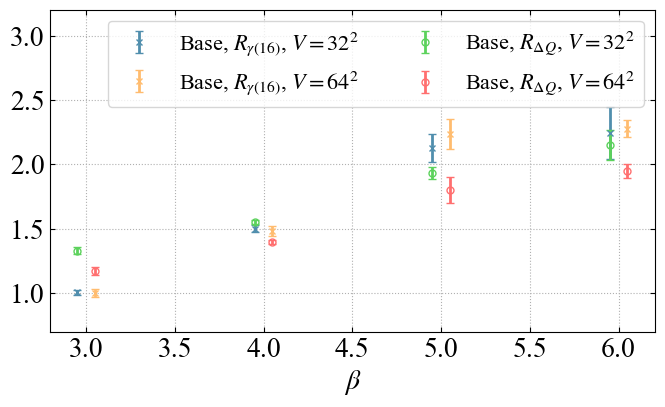

In [44]:

fig, ax = default_plot()

ax.errorbar(np.arange(3, 7)-0.05, [gv.mean(gamma_ratio_L32_b3), gv.mean(gamma_ratio_L32_b4), gv.mean(gamma_ratio_L32_b5), gv.mean(gamma_ratio_L32_b6)], yerr=[gv.sdev(gamma_ratio_L32_b3), gv.sdev(gamma_ratio_L32_b4), gv.sdev(gamma_ratio_L32_b5), gv.sdev(gamma_ratio_L32_b6)], label='Base, $R_{\\gamma (16)}$, $V=32^2$', color=color_ls[0], marker='x', **errorb)

ax.errorbar(np.arange(3, 7)+0.05, [gv.mean(gamma_ratio_L64_b3), gv.mean(gamma_ratio_L64_b4), gv.mean(gamma_ratio_L64_b5), gv.mean(gamma_ratio_L64_b6)], yerr=[gv.sdev(gamma_ratio_L64_b3), gv.sdev(gamma_ratio_L64_b4), gv.sdev(gamma_ratio_L64_b5), gv.sdev(gamma_ratio_L64_b6)], label='Base, $R_{\\gamma (16)}$, $V=64^2$', color=color_ls[1], marker='x', **errorb)

ax.errorbar(np.arange(3, 7)-0.05, [gv.mean(deltaQ_ratio_L32_b3), gv.mean(deltaQ_ratio_L32_b4), gv.mean(deltaQ_ratio_L32_b5), gv.mean(deltaQ_ratio_L32_b6)], yerr=[gv.sdev(deltaQ_ratio_L32_b3), gv.sdev(deltaQ_ratio_L32_b4), gv.sdev(deltaQ_ratio_L32_b5), gv.sdev(deltaQ_ratio_L32_b6)], label='Base, $R_{\\Delta Q}$, $V=32^2$', color=color_ls[2], **errorb_circle)

ax.errorbar(np.arange(3, 7)+0.05, [gv.mean(deltaQ_ratio_L64_b3), gv.mean(deltaQ_ratio_L64_b4), gv.mean(deltaQ_ratio_L64_b5), gv.mean(deltaQ_ratio_L64_b6)], yerr=[gv.sdev(deltaQ_ratio_L64_b3), gv.sdev(deltaQ_ratio_L64_b4), gv.sdev(deltaQ_ratio_L64_b5), gv.sdev(deltaQ_ratio_L64_b6)], label='Base, $R_{\\Delta Q}$, $V=64^2$', color=color_ls[3],  **errorb_circle)

ax.set_ylim(0.7, 3.2)
ax.legend(ncol=2, loc='upper right', fontsize=16)
ax.set_xlabel('$\\beta$', **fs_p)
plt.tight_layout()
plt.savefig('plots/scaling_performance.pdf', transparent=True)
plt.show()